In [1]:
!git clone https://github.com/varaiitj2527/PRMLProject.git
%cd PRMLProject

Cloning into 'PRMLProject'...
remote: Enumerating objects: 95, done.
remote: Counting objects: 100% (77/77), done.
remote: Compressing objects: 100% (68/68), done.
remote: Total 95 (delta 21), reused 22 (delta 2), pack-reused 18 (from 2)
Receiving objects: 100% (95/95), 205.17 MiB | 26.54 MiB/s, done.
Resolving deltas: 100% (21/21), done.
Updating files: 100% (38/38), done.
Filtering content: 100% (14/14), 1.29 GiB | 39.85 MiB/s, done.
Encountered 2 file(s) that should have been pointers, but weren't:
	PreProcessedData/quicknet_test.pkl
	PreProcessedData/quicknet_train.pkl
/content/PRMLProject


In [2]:
import numpy as np
from skimage.feature import hog
from tqdm import tqdm
import pickle
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, GridSearchCV
import matplotlib.pyplot as plt

In [3]:
def unpickle(filename) :

  with open(filename, 'rb') as file :
      data = pickle.load(file, encoding='bytes')

  return data

In [ ]:
train_RawData = unpickle('PreProcessedData/RawPixels_train.pkl')
test_RawData = unpickle('PreProcessedData/RawPixels_test.pkl')

train_labels = unpickle('PreProcessedData/Labels_train.pkl')
test_labels = unpickle('PreProcessedData/Labels_test.pkl')

train_PcaData = unpickle('PreProcessedData/TrainFeaturesPCA.pkl')
test_PcaData = unpickle('PreProcessedData/TestFeaturesPCA.pkl')

train_HoGData = unpickle('PreProcessedData/TrainFeaturesHoG.pkl')
test_HoGData = unpickle('PreProcessedData/TestFeaturesHoG.pkl')

train_Pca_HoGData = unpickle('PreProcessedData/TrainFeaturesPCA_HoG.pkl')
test_Pca_HoGData = unpickle('PreProcessedData/TestFeaturesPCA_HoG.pkl')

train_HoG_PcaData = unpickle('PreProcessedData/TrainFeaturesHoG_PCA.pkl')
test_HoG_PcaData = unpickle('PreProcessedData/TestFeaturesHoG_PCA.pkl')

In [ ]:
X_train = [train_RawData.reshape(-1,3072),train_HoGData,train_PcaData,train_HoG_PcaData,train_Pca_HoGData]
y_train = train_labels
X_test = [test_RawData.reshape(-1,3072),test_HoGData,test_PcaData,test_HoG_PcaData,test_Pca_HoGData]
y_test = test_labels

In [ ]:
print('Number of Training Samples ---> ',y_train.shape[0])
print('Dimensions of a Sample of RawData ---> ', X_train[0].shape[1])
print('Dimensions of a Sample of HoGData ---> ',X_train[1].shape[1])
print('Dimensions of a Sample of PCAData ---> ',X_train[2].shape[1])
print('Dimensions of a Sample of HoG_PCAData ---> ',X_train[3].shape[1])
print('Dimensions of a Sample of PCA_HoGData ---> ',X_train[4].shape[1])

Number of Training Samples --->  50000
Dimensions of a Sample of RawData --->  3072
Dimensions of a Sample of HoGData --->  324
Dimensions of a Sample of PCAData --->  658
Dimensions of a Sample of HoG_PCAData --->  170
Dimensions of a Sample of PCA_HoGData --->  324


In [ ]:
'''
    Splitting the Training Data into Training and Validation Sets in ratio 80:20
'''
X_val = []
y_val = []
y_ = y_train
y_trains = []
for i in range(5) :
  X_train[i], x_val, y_Train, Y_val = train_test_split(X_train[i], y_, test_size=0.2, random_state=42)
  X_val.append(x_val)
  y_val.append(Y_val)
  y_trains.append(y_Train)
  y_ = y_train

y_train = y_trains

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from tqdm import tqdm

def trainRandomForest(X_train, y_train, n_estimators, max_depth, criterion):
    '''
      Fits a Random Forest for the given data, number of trees (n_estimators),
      and impurity criterion.
    '''
    forest = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, criterion=criterion, random_state=42)
    forest.fit(X_train, y_train)
    return forest

def RunningMaxDepth(X_train, y_train, X_val, y_val, n_estimators, criterion):
    '''
      Finds the max_depth for which the Random Forest performs optimally.
    '''
    print('Building the Fully grown Random Forest')
    forests = []
    max_depth = 100
    train_accuracies = []
    validation_accuracies = []
    for depth in tqdm(range(1, max_depth)):
        forest = trainRandomForest(X_train, y_train, n_estimators, depth, criterion)
        train_accuracy = forest.score(X_train, y_train)
        validation_accuracy = forest.score(X_val, y_val)
        train_accuracies.append(train_accuracy)
        validation_accuracies.append(validation_accuracy)
        forests.append(forest)
        if train_accuracy >= 0.99:
            max_depth = depth
            break
    return max_depth, train_accuracies, validation_accuracies, forests

def plot_accuracies_vs_depths(depths, train_accuracies, validation_accuracies, title_string):
    '''
        Helping function to plot accuracy vs depth plots
    '''
    plt.figure(figsize=(8, 5))
    plt.plot(depths, train_accuracies, marker='o', linestyle='--', color='r', label='Training Accuracy')
    plt.plot(depths, validation_accuracies, marker='o', linestyle='-', color='b', label='Validation Accuracy')
    plt.xlabel('Depth')
    plt.ylabel('Accuracy')
    plt.title('Depth vs Accuracy ' + title_string)
    plt.xticks(depths)
    plt.legend()
    plt.show()

def RandomForest(X_train, y_train, criterion, X_val, y_val, n_estimators=100):
    Max_depth, train_accuracies, validation_accuracies, Forests = RunningMaxDepth(X_train, y_train, X_val, y_val, n_estimators, criterion)

    optimal_depth = validation_accuracies.index(max(validation_accuracies)) + 1
    optimal_forest = Forests[optimal_depth - 1]

    return optimal_forest, optimal_depth, train_accuracies, validation_accuracies, Max_depth

def predict(forest, X_test):
    return forest.predict(X_test)

def testAccuracy(LabelsPrediction, LabelsActual):
    return np.sum(LabelsPrediction == LabelsActual) / len(LabelsActual)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

def trainRandomForest(X_train, y_train, max_depth, criterion, n_estimators=100):
    '''
      Fits a Random Forest model for the given data, impurity measure, and number of estimators.
    '''
    forest = RandomForestClassifier(n_estimators=n_estimators, criterion=criterion, max_depth=max_depth, random_state=42)
    forest.fit(X_train, y_train)
    return forest

def RunningMaxDepthRF(X_train, y_train, X_val, y_val, criterion, n_estimators=100):
    '''
      Finds the max_depth of the Random Forest that optimizes validation accuracy.
    '''
    print('Building the Fully grown Random Forest')
    forests = []
    max_depth = 100
    train_accuracies = []
    validation_accuracies = []

    for depth in tqdm(range(1, max_depth)):
        forest = trainRandomForest(X_train, y_train, depth, criterion, n_estimators)
        train_accuracy = forest.score(X_train, y_train)
        validation_accuracy = forest.score(X_val, y_val)
        train_accuracies.append(train_accuracy)
        validation_accuracies.append(validation_accuracy)
        forests.append(forest)

        if train_accuracy >= 0.99:
            max_depth = depth
            break

    return max_depth, train_accuracies, validation_accuracies, forests

def RandomForest(X_train, y_train, criterion, X_val, y_val, n_estimators=100):
    '''
      Trains Random Forest and finds optimal depth.
    '''
    Max_depth, train_accuracies, validation_accuracies, Forests = RunningMaxDepthRF(X_train, y_train, X_val, y_val, criterion, n_estimators)

    optimal_depth = validation_accuracies.index(max(validation_accuracies)) + 1
    optimal_forest = Forests[optimal_depth-1]

    return optimal_forest, optimal_depth, train_accuracies, validation_accuracies, Max_depth


In [ ]:
OptimalForest_HoG_PCA, OptimalDepth_HoG_PCA, TrainAcc_HoG_PCA, ValAcc_HoG_PCA, MaxDepth_HoG_PCA = RandomForest(X_train[3], y_train[3], 'entropy', X_val[3], y_val[3])
OptimalForest_PCA, OptimalDepth_PCA, TrainAcc_PCA, ValAcc_PCA, MaxDepth_PCA = RandomForest(X_train[2], y_train[2], 'entropy', X_val[2], y_val[2])
OptimalForest_HoG, OptimalDepth_HoG, TrainAcc_HoG, ValAcc_HoG, MaxDepth_HoG = RandomForest(X_train[1], y_train[1], 'entropy', X_val[1], y_val[1])
OptimalForest_PCA_HoG, OptimalDepth_PCA_HoG, TrainAcc_PCA_HoG, ValAcc_PCA_HoG, MaxDepth_PCA_HoG = RandomForest(X_train[4], y_train[4], 'entropy', X_val[4], y_val[4])

Building the Fully grown Random Forest


 14%|█▍        | 14/99 [33:09<3:21:17, 142.09s/it]


Building the Fully grown Random Forest


 16%|█▌        | 16/99 [1:21:24<7:02:17, 305.28s/it]


Building the Fully grown Random Forest


 14%|█▍        | 14/99 [44:06<4:27:45, 189.01s/it]


Building the Fully grown Random Forest


 13%|█▎        | 13/99 [39:35<4:21:53, 182.71s/it]


In [ ]:
Predictions_HoG_PCA = predict(OptimalForest_HoG_PCA, X_test[3])
Predictions_PCA = predict(OptimalForest_PCA, X_test[2])
Predictions_HoG = predict(OptimalForest_HoG, X_test[1])
Predictions_PCA_HoG = predict(OptimalForest_PCA_HoG, X_test[4])

In [ ]:
Accuracy_HoG_PCA = testAccuracy(Predictions_HoG_PCA, y_test)
print('Random Forest Testing accuracy for HoG_PCA --->', Accuracy_HoG_PCA, '  Optimal Depth --->', OptimalDepth_HoG_PCA)

Accuracy_PCA = testAccuracy(Predictions_PCA, y_test)
print('Random Forest Testing accuracy for PCA --->', Accuracy_PCA, '  Optimal Depth --->', OptimalDepth_PCA)

Accuracy_HoG = testAccuracy(Predictions_HoG, y_test)
print('Random Forest Testing accuracy for HoG --->', Accuracy_HoG, '  Optimal Depth --->', OptimalDepth_HoG)

Accuracy_PCA_HoG = testAccuracy(Predictions_PCA_HoG, y_test)
print('Random Forest Testing accuracy for PCA_HoG --->', Accuracy_PCA_HoG, '  Optimal Depth --->', OptimalDepth_PCA_HoG)


Random Forest Testing accuracy for HoG_PCA ---> 0.4838   Optimal Depth ---> 14
Random Forest Testing accuracy for PCA ---> 0.3944   Optimal Depth ---> 15
Random Forest Testing accuracy for HoG ---> 0.5064   Optimal Depth ---> 14
Random Forest Testing accuracy for PCA_HoG ---> 0.4646   Optimal Depth ---> 14


In [ ]:
OptimalForest_Raw, OptimalDepth_Raw, TrainAcc_Raw, ValAcc_Raw, MaxDepth_Raw = RandomForest(X_train[0], y_train[0], 'entropy', X_val[0], y_val[0])
Predictions_Raw = predict(OptimalForest_Raw, X_test[0])
Accuracy_Raw = testAccuracy(Predictions_Raw, y_test)
print('Random Forest Testing accuracy for Raw --->', Accuracy_Raw, '  Optimal Depth --->', OptimalDepth_Raw)


Building the Fully grown Random Forest


 15%|█▌        | 15/99 [53:58<5:02:13, 215.88s/it]


Random Forest Testing accuracy for Raw ---> 0.4583   Optimal Depth ---> 16


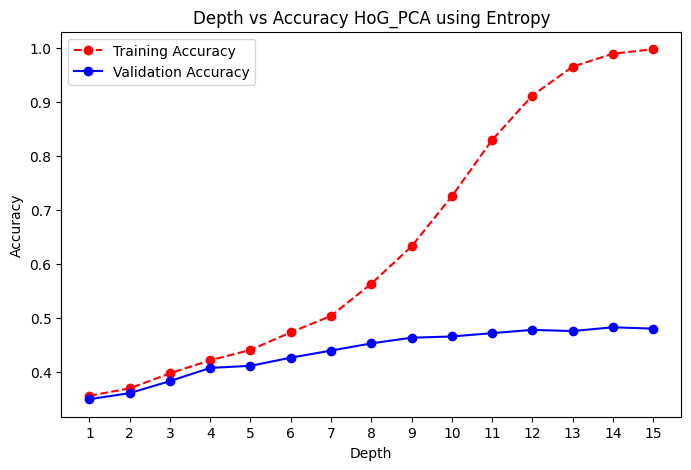

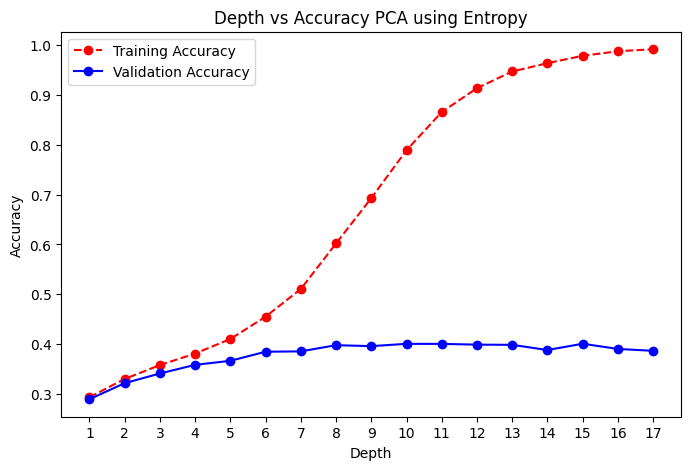

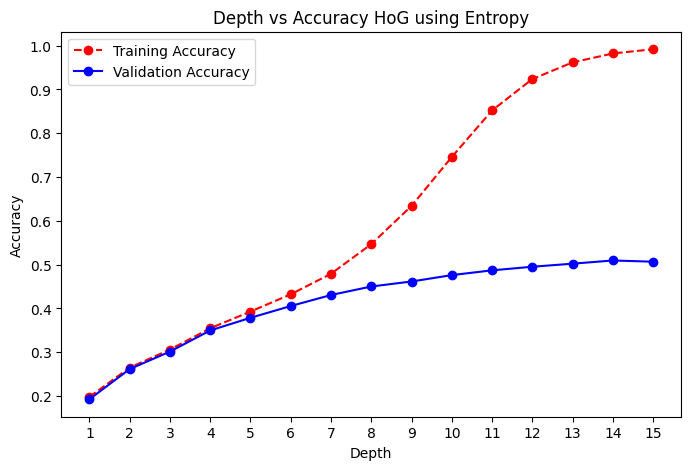

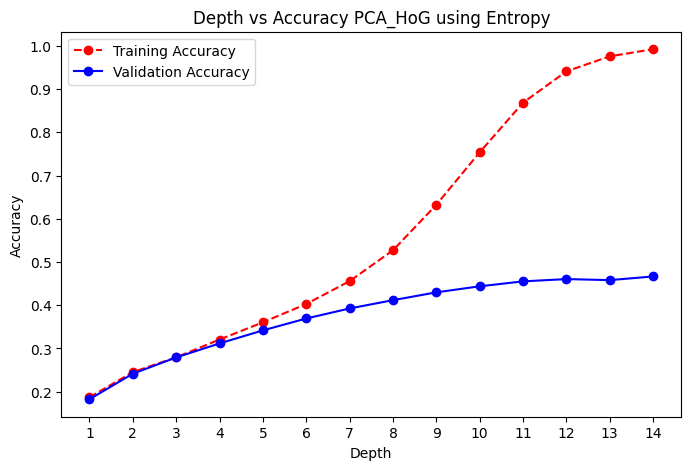

In [ ]:
plot_accuracies_vs_depths(range(1, MaxDepth_HoG_PCA+1), TrainAcc_HoG_PCA, ValAcc_HoG_PCA, 'HoG_PCA using Entropy')
plot_accuracies_vs_depths(range(1, MaxDepth_PCA+1), TrainAcc_PCA, ValAcc_PCA, 'PCA using Entropy')
plot_accuracies_vs_depths(range(1, MaxDepth_HoG+1), TrainAcc_HoG, ValAcc_HoG, 'HoG using Entropy')
plot_accuracies_vs_depths(range(1, MaxDepth_PCA_HoG+1), TrainAcc_PCA_HoG, ValAcc_PCA_HoG, 'PCA_HoG using Entropy')


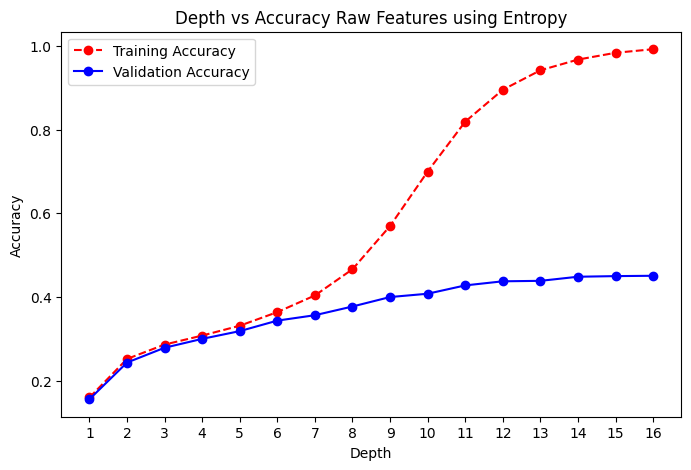

In [ ]:
plot_accuracies_vs_depths(range(1, MaxDepth_Raw+1), TrainAcc_Raw, ValAcc_Raw, 'Raw Features using Entropy')


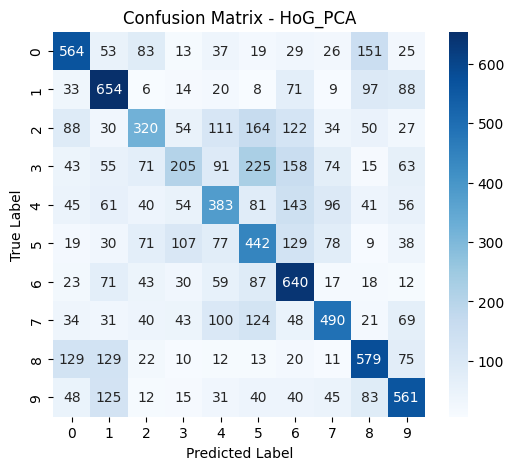

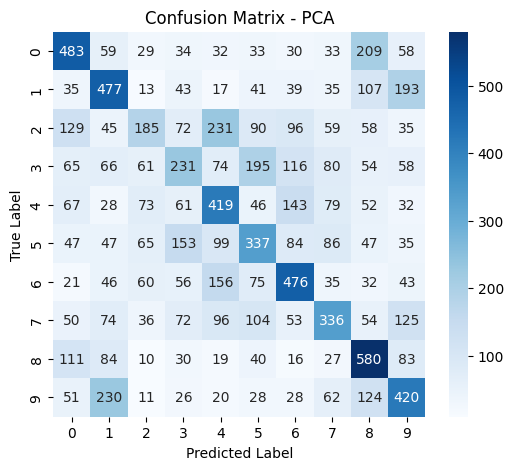

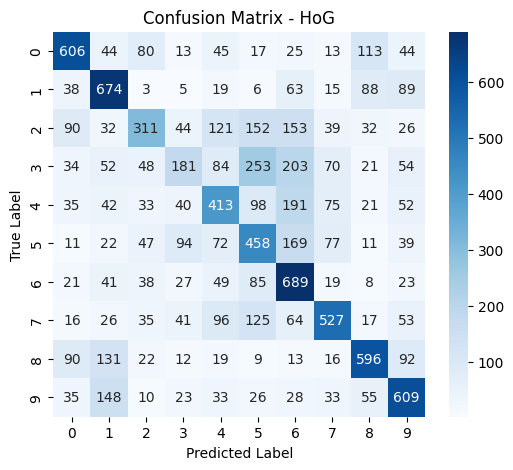

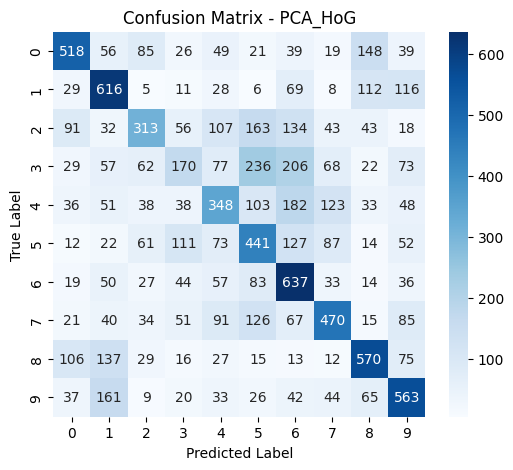

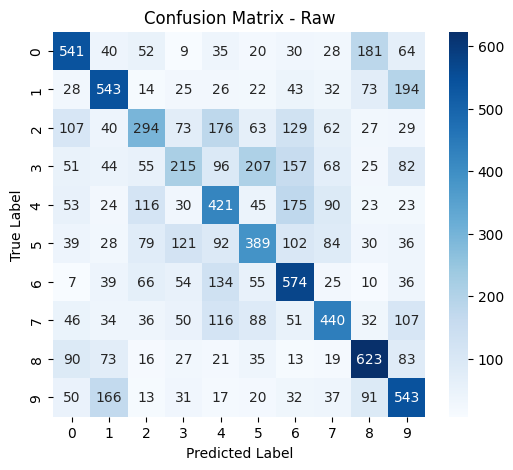

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=set(y_true), yticklabels=set(y_true))
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(title)
    plt.show()

# Generate confusion matrices for each model
plot_confusion_matrix(y_test, Predictions_HoG_PCA, "Confusion Matrix - HoG_PCA")
plot_confusion_matrix(y_test, Predictions_PCA, "Confusion Matrix - PCA")
plot_confusion_matrix(y_test, Predictions_HoG, "Confusion Matrix - HoG")
plot_confusion_matrix(y_test, Predictions_PCA_HoG, "Confusion Matrix - PCA_HoG")
plot_confusion_matrix(y_test, Predictions_Raw, "Confusion Matrix - Raw")


In [14]:
import pickle
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Helper function to unpickle files
def unpickle(file_path):
    with open(file_path, 'rb') as f:
        return pickle.load(f)

# --- Load QuickNet Features ---
quicknet_train_data = unpickle('/content/quicknet_train.pkl')
quicknet_test_data = unpickle('/content/quicknet_test.pkl')

# --- Load ResNet Features ---
resnet_train_data = unpickle('/content/Resnet_train.pkl')
resnet_test_data = unpickle('/content/Resnet_test.pkl')

# --- Load Labels ---
train_labels = unpickle('/content/Labels_train.pkl')
test_labels = unpickle('/content/Labels_test.pkl')

# --- Convert to NumPy Arrays ---
train_QuickNetData = np.array(quicknet_train_data)
test_QuickNetData = np.array(quicknet_test_data)

train_ResNetData = np.array(resnet_train_data)
test_ResNetData = np.array(resnet_test_data)

train_labels = np.array(train_labels)
test_labels = np.array(test_labels)


print("Number of Training Samples:", train_labels.shape[0])
print("Number of Testing Samples:", test_labels.shape[0])
print("QuickNet Feature Shape:", train_QuickNetData.shape)
print("ResNet Feature Shape:", train_ResNetData.shape)

Number of Training Samples: 50000
Number of Testing Samples: 10000
QuickNet Feature Shape: (50000, 512)
ResNet Feature Shape: (50000, 2048)


QuickNet + Random Forest Accuracy (Entropy): 0.7348
ResNet + Random Forest Accuracy (Entropy): 0.8334


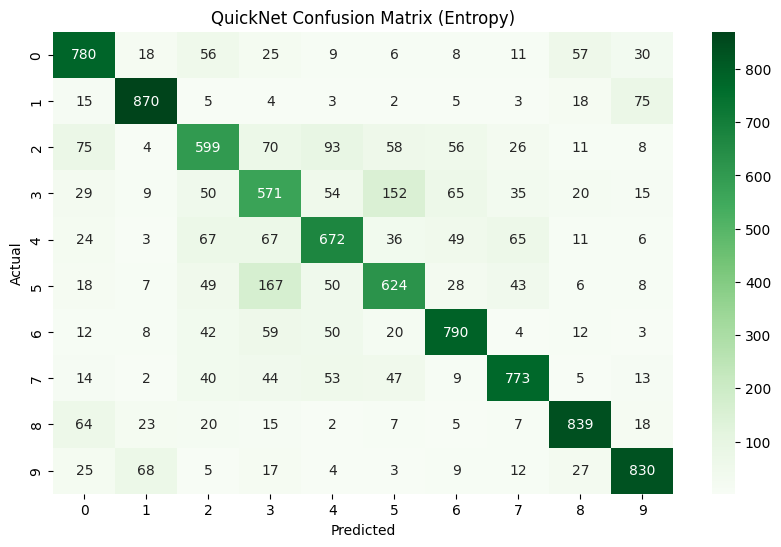

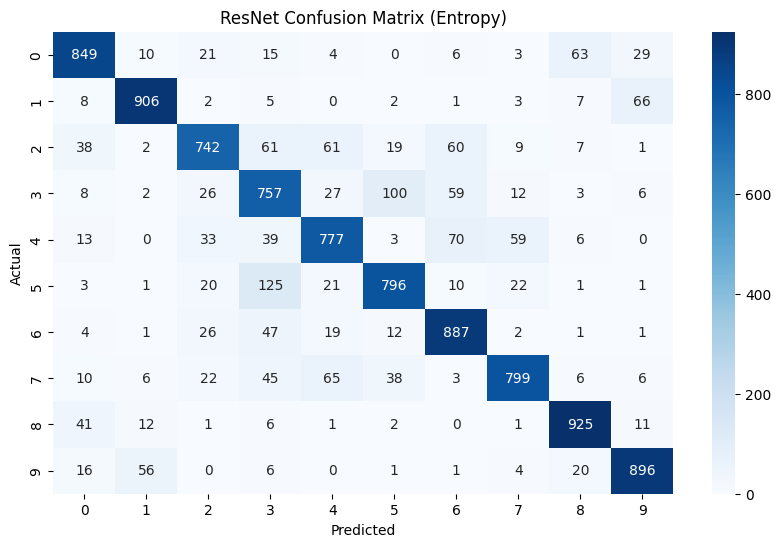

In [16]:
# --- Random Forest Classifier with Entropy ---

# QuickNet Classifier
clf_quicknet = RandomForestClassifier(n_estimators=100, criterion='entropy', random_state=42)
clf_quicknet.fit(train_QuickNetData, train_labels)
y_pred_quicknet = clf_quicknet.predict(test_QuickNetData)
acc_quicknet = accuracy_score(test_labels, y_pred_quicknet)
print("QuickNet + Random Forest Accuracy (Entropy):", acc_quicknet)

# ResNet Classifier
clf_resnet = RandomForestClassifier(n_estimators=100, criterion='entropy', random_state=42)
clf_resnet.fit(train_ResNetData, train_labels)
y_pred_resnet = clf_resnet.predict(test_ResNetData)
acc_resnet = accuracy_score(test_labels, y_pred_resnet)
print("ResNet + Random Forest Accuracy (Entropy):", acc_resnet)

# --- Confusion Matrix for QuickNet ---
plt.figure(figsize=(10, 6))
sns.heatmap(confusion_matrix(test_labels, y_pred_quicknet), annot=True, fmt='d', cmap='Greens')
plt.title("QuickNet Confusion Matrix (Entropy)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# --- Confusion Matrix for ResNet ---
plt.figure(figsize=(10, 6))
sns.heatmap(confusion_matrix(test_labels, y_pred_resnet), annot=True, fmt='d', cmap='Blues')
plt.title("ResNet Confusion Matrix (Entropy)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()